In [214]:
#importing libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

from datetime import datetime

In [215]:
#reading data
df = pd.read_csv("C:/Users/ABHYUDAY/Desktop/Food.csv", encoding = "Latin-1")

In [216]:
df.shape

(45593, 11)

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


In [218]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


# Quick Data Analysis

In [219]:
df.select_dtypes(exclude='object').describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


## Checking Null Values

In [220]:
def check_null(df):
    '''Returns % null values in each column'''
    return round(100*df.isnull().sum()/len(df), 2).sort_values(ascending=False)
check_null(df)

ID                             0.0
Delivery_person_ID             0.0
Delivery_person_Age            0.0
Delivery_person_Ratings        0.0
Restaurant_latitude            0.0
Restaurant_longitude           0.0
Delivery_location_latitude     0.0
Delivery_location_longitude    0.0
Type_of_order                  0.0
Type_of_vehicle                0.0
Time_taken(min)                0.0
dtype: float64

# EDA

## Univariate Analysis

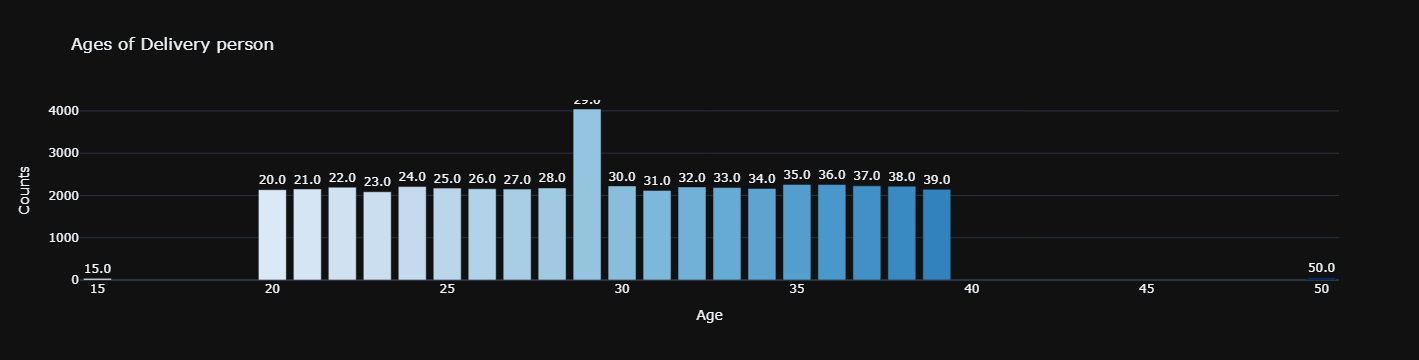

In [221]:
age_counts = df['Delivery_person_Age'].value_counts(sort=False).reset_index().sort_values(by = 'count')
fig = px.bar(data_frame=age_counts, y='count', x='Delivery_person_Age', title="Ages of Delivery person",
            color='Delivery_person_Age',text='Delivery_person_Age',color_continuous_scale='blues',
             template="plotly_dark")
fig.update_traces(texttemplate='%{text:.3s}', textposition='outside')
fig.update_layout(xaxis_title = "Age", yaxis_title="Counts")
fig.update_coloraxes(showscale=False)
fig.show()

### Most of the Delivery Person are aged between 20 to 39, although we have some agents of age 15 and 50

In [222]:
df = df[(df["Delivery_person_Age"] != 15) & 
        (df["Delivery_person_Age"] != 50)]

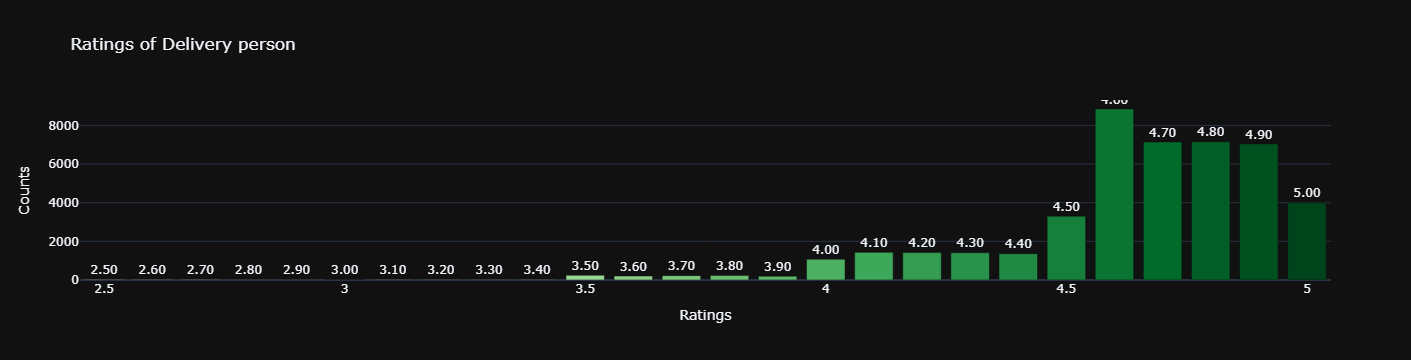

In [223]:
age_counts = df['Delivery_person_Ratings'].value_counts(sort=False).reset_index().sort_values(by='count')
fig = px.bar(data_frame=age_counts, y='count', x='Delivery_person_Ratings', title="Ratings of Delivery person",
            color='Delivery_person_Ratings',text='Delivery_person_Ratings',color_continuous_scale='greens',
             template="plotly_dark")
fig.update_traces(texttemplate='%{text:.3s}', textposition='outside')
fig.update_layout(yaxis_title = "Counts", xaxis_title="Ratings")
fig.update_coloraxes(showscale=False)
fig.show()

### Most of the Ratings are between 4 to 5, but we have 53 ratings equal to 6. We chage all 53 to 5.

In [224]:
def ratings(x):
    if x<1:
        return 1
    elif x>5:
        return 5
    return x

In [225]:
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].apply(ratings)

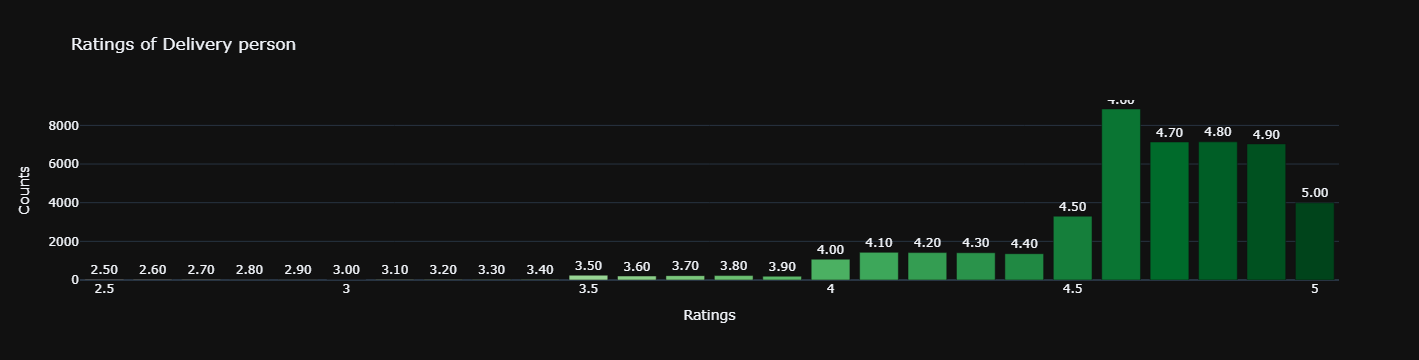

In [226]:
age_counts = df['Delivery_person_Ratings'].value_counts(sort=False).reset_index().sort_values(by='count')
fig = px.bar(data_frame=age_counts, y='count', x='Delivery_person_Ratings', title="Ratings of Delivery person",
            color='Delivery_person_Ratings',text='Delivery_person_Ratings',color_continuous_scale='greens',
             template="plotly_dark")
fig.update_traces(texttemplate='%{text:.3s}', textposition='outside')
fig.update_layout(yaxis_title = "Counts", xaxis_title="Ratings")
fig.update_coloraxes(showscale=False)
fig.show()


##### Changed all 5+ ratings to 5.00

In [227]:
def plot_measures(measures):
    n = len(measures)
    rows, cols = 2, (n//2)
    titles = [" ".join(col.split('_')).title() for col in measures]
    fig = make_subplots(rows=rows, cols=cols,subplot_titles=titles)
    for idx, col in enumerate(measures):
        i,j = (idx//cols), (idx%cols)
        col_df = df[col].value_counts(sort=False).reset_index().sort_values(by='count')
        fig.add_trace(go.Bar(y=col_df['count'],x=col_df[col], name=titles[idx]),row = i+1,col=j+1)
    
    fig.update_layout(title=f"Distribution of Categorical Variables", template = 'plotly_dark',
                                 height=900,width=950, showlegend=False)
        
    return fig

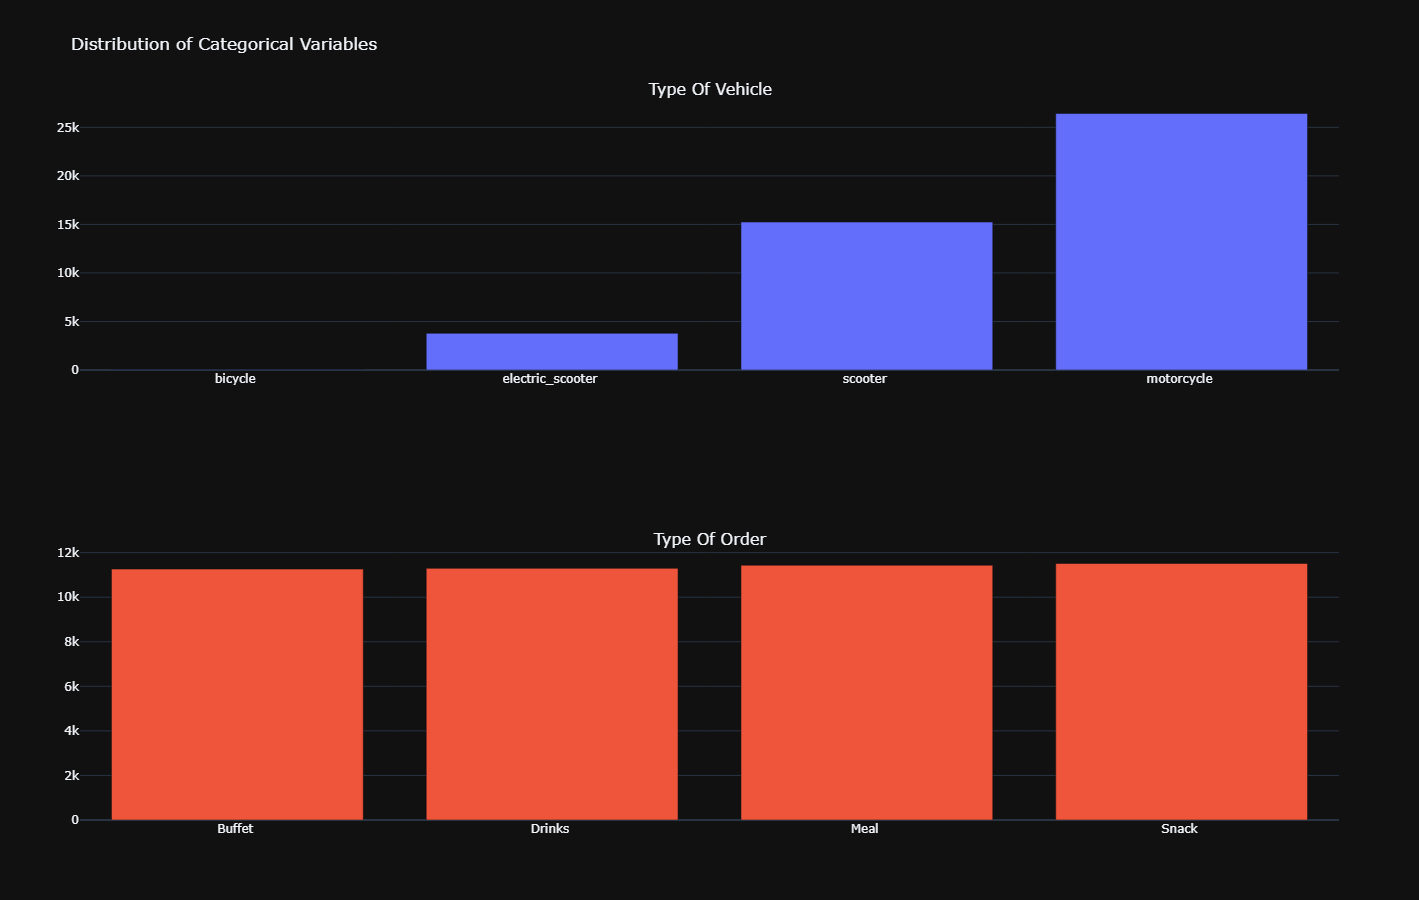

In [228]:
fig = plot_measures(['Type_of_vehicle','Type_of_order'])
fig.show()

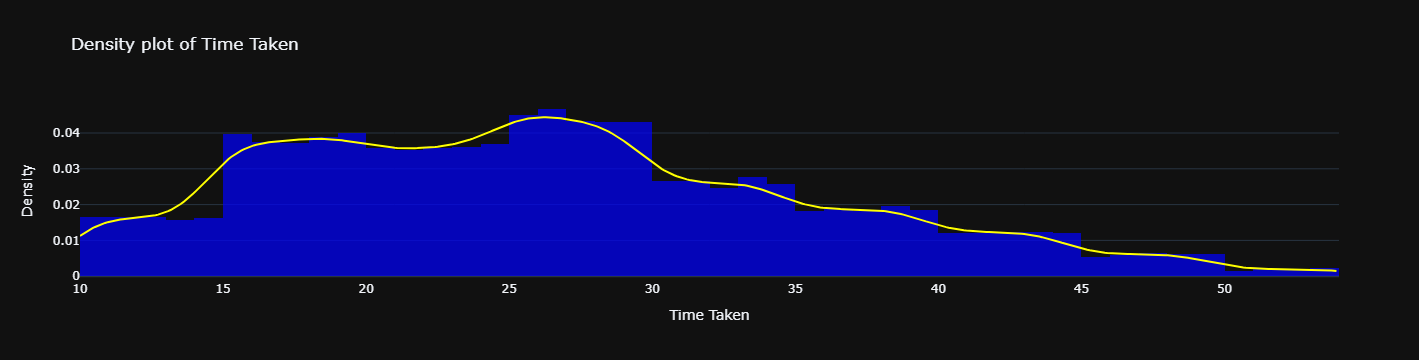

In [229]:

fig = ff.create_distplot(hist_data = [df['Time_taken(min)'].values], group_labels=['Time Taken'], show_rug=False)
fig.update_layout(xaxis_title = "Time Taken", yaxis_title="Density",
                  title = "Density plot of Time Taken", showlegend=False, template = 'plotly_dark')
fig.update_traces(marker_color='blue', selector=dict(type='histogram'))
fig.update_traces(line_color='yellow', selector=dict(type='scatter'))
fig.show()

##### Distribution shape

The distribution is right-skewed (positively skewed)

Most deliveries happen faster
Few deliveries take much longer → long tail

## Bi-Variate Analysis

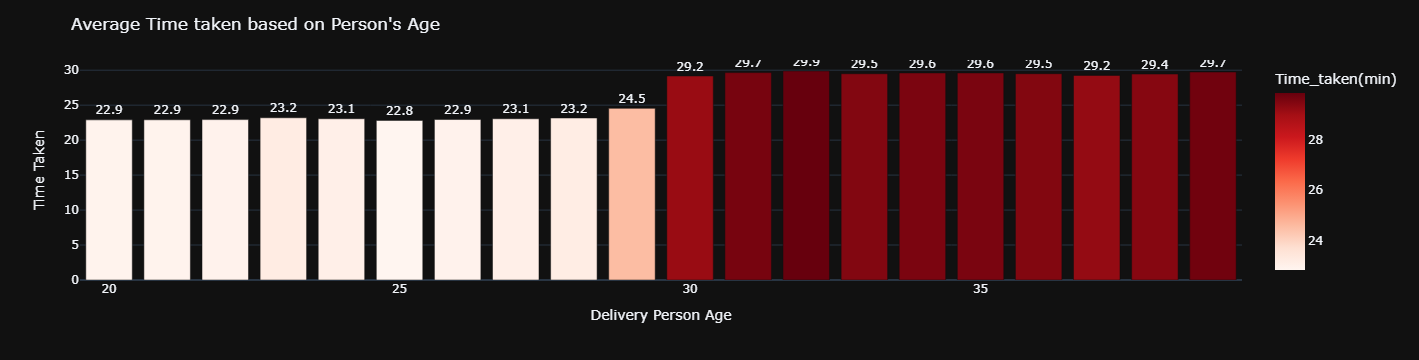

In [230]:
grp_df = df.groupby('Delivery_person_Age', as_index=False)['Time_taken(min)'].mean()
fig = px.bar(data_frame=grp_df, x = "Delivery_person_Age", y='Time_taken(min)', text='Time_taken(min)',
             color='Time_taken(min)', color_continuous_scale='reds')
fig.update_traces(texttemplate='%{text:.3s}', textposition='outside')
fig.update_layout(xaxis_title = "Delivery Person Age", yaxis_title="Time Taken",
                  title = "Average Time taken based on Person's Age", showlegend=False, template = 'plotly_dark',)
fig.show()

##### The analysis examines the relationship between delivery personnel age and the average delivery time. 
The visualization shows that delivery time remains relatively stable across most age groups, generally ranging between 22 and 30 minutes. Younger delivery personnel (ages 20–28) tend to exhibit slightly faster average delivery times, typically around 23 minutes, suggesting higher physical agility and efficiency. In contrast, delivery personnel aged 30–39 demonstrate marginally higher average delivery times, close to 29–30 minutes, indicating a minor increase in delivery duration with age. However, the overall variation across age groups is limited, implying that age is not a dominant factor influencing delivery performance. Extreme age values (e.g., 15 and 50 years) show deviations, likely due to smaller sample sizes or data irregularities.

Overall, the results suggest that operational factors such as distance, traffic, and order preparation time may have a stronger impact on delivery time than the age of the delivery personnel.

#### Delivery Agents aged above 30 tends to take more time then the Agents aged between 20 to 30.

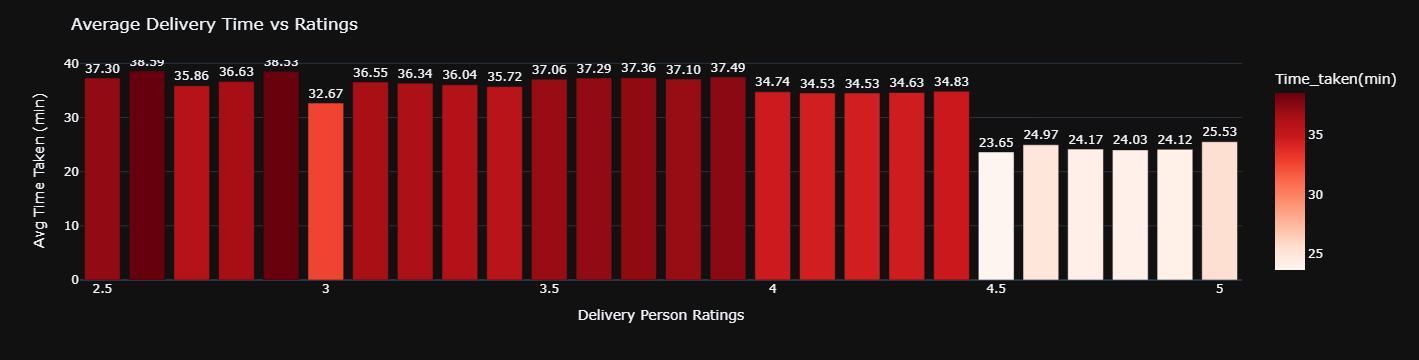

In [231]:
grp_df = (
    df.groupby('Delivery_person_Ratings', as_index=False)['Time_taken(min)']
    .mean()
)

fig = px.bar(
    data_frame=grp_df,
    x="Delivery_person_Ratings",    
    y='Time_taken(min)',              
    text='Time_taken(min)',
    color='Time_taken(min)',
    color_continuous_scale='reds'
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title="Delivery Person Ratings",
    yaxis_title="Avg Time Taken (min)",
    title="Average Delivery Time vs Ratings",
    showlegend=False,
    template='plotly_dark'
)

fig.show()

##### The analysis explores the relationship between delivery personnel ratings and the average delivery time.
The visualization indicates a negative relationship between ratings and delivery duration. Delivery personnel with higher ratings (4.5–5.0) consistently achieve faster delivery times, averaging approximately 23–26 minutes, suggesting superior efficiency and service quality. Conversely, delivery personnel with moderate ratings (2.5–4.3) exhibit longer delivery times, generally between 34–38 minutes, indicating potential performance inefficiencies.

An isolated low-rating observation (rating ≈ 1) shows relatively lower delivery time, which may be attributed to data sparsity or anomalous entries rather than a true performance pattern. Overall, the findings suggest that delivery ratings can serve as a meaningful proxy for operational efficiency, where higher-rated personnel tend to deliver orders more quickly.

#### It can be observed there is a sudden drop in Time taken from Ratings 4.5 and greater.

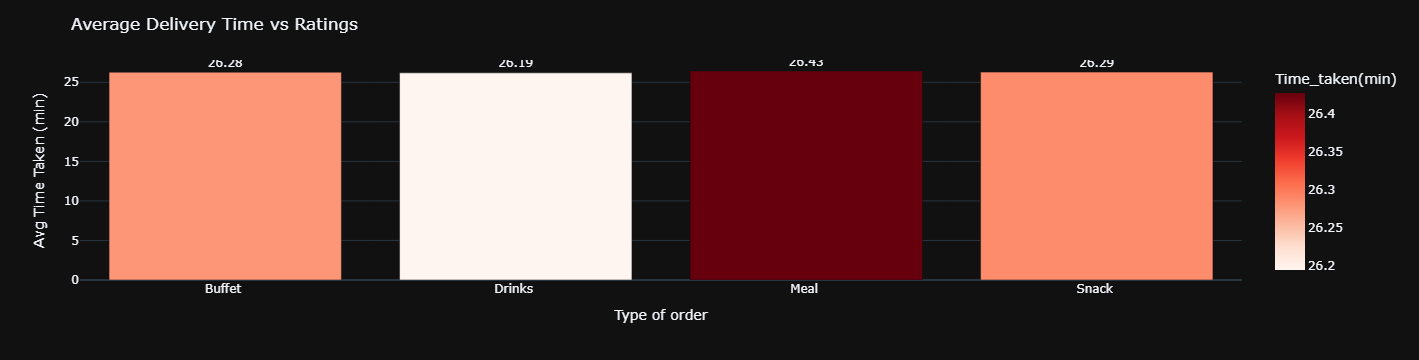

In [232]:
grp_df = (
    df.groupby('Type_of_order', as_index=False)['Time_taken(min)']
    .mean()
)

fig = px.bar(
    data_frame=grp_df,
    x="Type_of_order",    
    y='Time_taken(min)',              
    text='Time_taken(min)',
    color='Time_taken(min)',
    color_continuous_scale='reds'
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title="Type of order",
    yaxis_title="Avg Time Taken (min)",
    title="Average Delivery Time vs Ratings",
    showlegend=False,
    template='plotly_dark'
)

fig.show()

#### The analysis examines the relationship between type of order and the average delivery time.

The average delivery time across different order types (Snack, Meal, Buffet, and Drinks) shows very minimal variation. Meals have the highest average delivery time (26.42 minutes), while Drinks have the lowest (26.19 minutes). However, the difference between categories is less than 0.3 minutes, indicating that the type of food does not significantly impact delivery time in this dataset.

Since the variation across order types is negligible, Type_of_order alone may not be a strong standalone predictor of delivery time. However, it may still contribute when interacting with other variables such as traffic density or multiple deliveries.

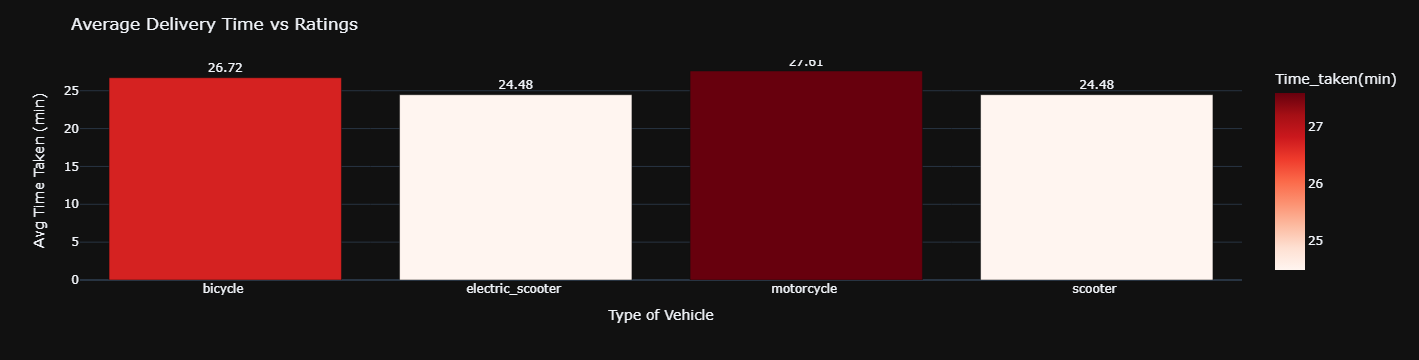

In [233]:
grp_df = (
    df.groupby('Type_of_vehicle', as_index=False)['Time_taken(min)']
    .mean()
)

fig = px.bar(
    data_frame=grp_df,
    x="Type_of_vehicle",    
    y='Time_taken(min)',              
    text='Time_taken(min)',
    color='Time_taken(min)',
    color_continuous_scale='reds'
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title="Type of Vehicle",
    yaxis_title="Avg Time Taken (min)",
    title="Average Delivery Time vs Ratings",
    showlegend=False,
    template='plotly_dark'
)

fig.show()

Impact of Vehicle Type on Delivery Time

This visualization shows the average delivery time across different vehicle types.
##### Observations

Motorcycles have the highest average delivery time (27.8 minutes).<br>
Bicycles also show relatively higher delivery times (26.5 minutes).<br>
Scooters and electric scooters have the lowest average delivery times (24.5 minutes).<br>

##### Interpretation
Although motorcycles are generally faster vehicles, the higher average delivery time may indicate:<br>
Longer delivery distances assigned to motorcycles.<br>
Higher order volume handled by motorcycle riders.<br>
Increased traffic exposure during peak hours.<br>

##### Electric scooters and scooters show lower delivery times, possibly due to:
Better maneuverability in traffic.<br>
Short-distance assignments.<br>
Urban route optimization.<br>


Vehicle type influences delivery efficiency and should be included as a predictive feature in the ETA model.
However, vehicle type alone does not determine delivery time. It likely interacts with other factors such as:
Distance<br>
Traffic density<br>
Multiple deliveries<br>
City<br>

##### Therefore, vehicle type will be used along with interaction features in the final model.

# Feature Engneering

In [234]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["distance_km"] = haversine(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

df = df[df["distance_km"] < 30]   # removing extreme long distances
df = df[df["Time_taken(min)"] < 120]
df["distance_km"].describe()

count    45103.000000
mean         9.734886
std          5.608545
min          1.465067
25%          4.663412
50%          9.220209
75%         13.681489
max         20.969489
Name: distance_km, dtype: float64

##### Accurate ETA prediction requires understanding the spatial relationship between pickup and drop locations.

We compute the Haversine Distance to estimate the direct geographical distance between the restaurant and customer coordinates. This feature captures the fundamental travel requirement for each order.<br>
##### Distance-based features are critical because:
-Travel time scales non-linearly with distance<br>
-Traffic impact increases over longer distances<br>
-Multiple deliveries amplify travel delay<br>
We further enhance this feature using logarithmic and square-root transformations to capture non-linear travel patterns.

##### We remove outliers in distance and time taken for the orders.

In [235]:
df["log_distance"] = np.log1p(df["distance_km"])
df["sqrt_distance"] = np.sqrt(df["distance_km"])
df["distance_sq"] = df["distance_km"] ** 2

df[["distance_km", "log_distance", "sqrt_distance"]].describe()

,distance_km,log_distance,sqrt_distance
count,45103.000000,45103.000000,45103.000000
mean,9.734886,2.205919,2.968913
std,5.608545,0.620996,0.959408
min,1.465067,0.902219,1.210400
25%,4.663412,1.734026,2.159493
50%,9.220209,2.324367,3.036480
75%,13.681489,2.686587,3.698850
max,20.969489,3.089655,4.579246


In [236]:
df["rating_age"] = df["Delivery_person_Ratings"] * df["Delivery_person_Age"]
df["rating_age"].describe()

count    45103.000000
mean       136.661457
std         26.887219
min         50.000000
25%        115.000000
50%        134.400000
75%        158.400000
max        195.000000
Name: rating_age, dtype: float64

In [237]:
df["speed"] = df["distance_km"] / df["Time_taken(min)"]
df['speed'].describe()
print(df.columns)
df = df.drop(['ID','Delivery_person_ID',"speed"],axis = 1)
print(df.columns)

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)', 'distance_km', 'log_distance', 'sqrt_distance',
       'distance_sq', 'rating_age', 'speed'],
      dtype='object')
Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)', 'distance_km', 'log_distance', 'sqrt_distance',
       'distance_sq', 'rating_age'],
      dtype='object')


# Model Selection: Why XGBoost?

For the delivery time prediction task, we selected XGBoost (Extreme Gradient Boosting) as our primary model.
Food delivery ETA prediction is a nonlinear regression problem influenced by multiple interacting factors such as distance, traffic density, weather conditions, vehicle type, and number of deliveries. These relationships are complex and cannot be effectively captured using simple linear models.

##### XGBoost is chosen for the following reasons:
-It handles nonlinear relationships effectively.<br>
-It automatically captures feature interactions.<br>
-It performs well on structured/tabular datasets.<br>
-It is robust to outliers and multicollinearity.<>

It provides strong regularization, reducing overfitting.
Additionally, prior comparative research on food delivery time prediction demonstrated that XGBoost outperformed traditional regression models such as Linear Regression, Decision Trees, Random Forest, and KNN in terms of MAE and R². Therefore, it serves as a strong and research-backed baseline for this problem.

###### Given these advantages, XGBoost is well-suited for building an accurate and reliable ETA prediction model.

Source: https://dergipark.org.tr/en/download/article-file/3824849

## Comparing the Top 3 Models to proof

In [238]:
import os
import joblib
from collections import defaultdict

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from sklearn.ensemble import VotingRegressor, StackingRegressor, RandomForestRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [239]:
X = df.drop("Time_taken(min)", axis=1)
y = df["Time_taken(min)"]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: split temp into validation and test (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (31572, 13)
Validation: (6765, 13)
Test: (6766, 13)


In [240]:
print(df.columns)

# Convert all columns except kfold to numeric
for col in df.columns:
    if col not in ["kfold"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# Reset index
df = df.reset_index(drop=True)
print(df.dtypes)

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)', 'distance_km', 'log_distance', 'sqrt_distance',
       'distance_sq', 'rating_age'],
      dtype='object')
Delivery_person_Age              int64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Type_of_order                  float64
Type_of_vehicle                float64
Time_taken(min)                  int64
distance_km                    float64
log_distance                   float64
sqrt_distance                  float64
distance_sq                    float64
rating_age                     float64
dtype: object


In [241]:
df = pd.get_dummies(
    df,
    columns=["Type_of_order", "Type_of_vehicle"],
    drop_first=True
)

from sklearn.model_selection import KFold

df["kfold"] = -1

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, valid_idx) in enumerate(kf.split(df)):
    df.loc[valid_idx, "kfold"] = fold
print(df.columns)

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Time_taken(min)', 'distance_km',
       'log_distance', 'sqrt_distance', 'distance_sq', 'rating_age', 'kfold'],
      dtype='object')


In [242]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

oof_preds = np.zeros(len(df))
xgb_models = []

for fold in range(5):

    print(f"Training Fold {fold}")

    train_idx = df[df.kfold != fold].index
    valid_idx = df[df.kfold == fold].index

    X_train = df.loc[train_idx].drop(["Time_taken(min)", "kfold"], axis=1)
    y_train = df.loc[train_idx]["Time_taken(min)"]

    X_valid = df.loc[valid_idx].drop(["Time_taken(min)", "kfold"], axis=1)
    y_valid = df.loc[valid_idx]["Time_taken(min)"]

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    xgb_models.append(model)

    oof_preds[valid_idx] = model.predict(X_valid)

mae = mean_absolute_error(df["Time_taken(min)"], oof_preds)
print("CV MAE:", mae)

Training Fold 0
Training Fold 1
Training Fold 2
Training Fold 3
Training Fold 4
CV MAE: 5.947608639130747
